In [1]:
from ultralytics import YOLO
import matplotlib.pyplot as plt

import os
import json
import shutil
import random
from pathlib import Path

In [3]:

model = YOLO("yolov8n.pt") # Load pre-trained YOLO model
#results = model("car.png")
#results[0].show() # Display results


In [2]:

# Paths
MTSD_ROOT = "mtsd"
ANNOTATIONS_DIR = f"{MTSD_ROOT}/mtsd_v2_fully_annotated/annotations"
IMAGES_DIR = f"{MTSD_ROOT}/images"
YOLO_DATASET = "mtsd_yolo_dataset"

# Create YOLO dataset structure
for split in ["train", "val", "test"]:
    for subdir in ["images", "labels"]:
        Path(f"{YOLO_DATASET}/{split}/{subdir}").mkdir(parents=True, exist_ok=True)

In [4]:
# =============================================================================
# Task 2: Prepare the Dataset - Convert MTSD to YOLO format
# =============================================================================
# MTSD uses JSON annotations with bbox format (xmin, ymin, xmax, ymax)
# YOLO requires: <class_id> <x_center> <y_center> <width> <height> (normalized 0-1)
# Use single class "traffic-sign" (0) for small object detection focus
# All MTSD labels map to class 0 - we're detecting presence, not fine-grained classification

CLASS_MAP = {"traffic-sign": 0}  # All signs -> 0

def mtsd_to_yolo_bbox(bbox, img_width, img_height):
    """Convert MTSD bbox (xmin, ymin, xmax, ymax) to YOLO format (x_center, y_center, w, h) normalized."""
    if "cross_boundary" in bbox:
        # Skip cross-boundary objects for simplicity (panorama edge case)
        return None
    xmin, ymin = bbox["xmin"], bbox["ymin"]
    xmax, ymax = bbox["xmax"], bbox["ymax"]
    x_center = (xmin + xmax) / 2 / img_width
    y_center = (ymin + ymax) / 2 / img_height
    width = (xmax - xmin) / img_width
    height = (ymax - ymin) / img_height
    # Validate
    if width <= 0 or height <= 0 or x_center < 0 or x_center > 1 or y_center < 0 or y_center > 1:
        return None
    return f"{x_center:.6f} {y_center:.6f} {width:.6f} {height:.6f}"

def convert_mtsd_to_yolo():
    """Convert MTSD annotations to YOLO format. Per assignment: randomly select 10-15% as test."""
    # Collect all available images with annotations
    available_keys = []
    for fname in os.listdir(ANNOTATIONS_DIR): #looking through the labels
        if not fname.endswith(".json"): 
            continue
        key = fname.replace(".json", "") #key is the filename 
        img_path = f"{IMAGES_DIR}/{key}.jpg" #matching image 
        ann_path = f"{ANNOTATIONS_DIR}/{key}.json" #matching annotation 
        if not os.path.exists(img_path):
            continue
        with open(ann_path) as f:
            ann = json.load(f) #
        lines = [] #empty list to store the yolo format 
        for obj in ann.get("objects", []): #looking through the "objects" in the annotation 
            yolo_bbox = mtsd_to_yolo_bbox(obj["bbox"], ann["width"], ann["height"]) #passing the bbox and the width and height to the function  of the image 
            if yolo_bbox:
                lines.append(f"{CLASS_MAP['traffic-sign']} {yolo_bbox}") #adding the yolo format to the list 
        if lines:
            available_keys.append((key, lines, img_path)) #availble image_id(key), lines(yolo format), img_path

    # Random split: 75% train, 10% val, 15% test (per assignment: 10-15% test)
    random.seed(42)
    random.shuffle(available_keys)
    n = len(available_keys)
    n_test = int(0.15 * n)
    n_val = int(0.10 * n)
    n_train = n - n_test - n_val
    splits = {
        "train": available_keys[:n_train],
        "val": available_keys[n_train : n_train + n_val],
        "test": available_keys[n_train + n_val :],
    }

    for split_name, items in splits.items():
        for key, lines, img_path in items:
            shutil.copy(img_path, f"{YOLO_DATASET}/{split_name}/images/{key}.jpg")
            with open(f"{YOLO_DATASET}/{split_name}/labels/{key}.txt", "w") as f:
                f.write("\n".join(lines))
        print(f"{split_name}: {len(items)} images")

convert_mtsd_to_yolo()

train: 13102 images
val: 1746 images
test: 2620 images


In [4]:
# Create dataset.yaml for YOLO training
dataset_yaml = f"""
path: {os.path.abspath(YOLO_DATASET)}
train: train/images
val: val/images
test: test/images

nc: 1
names: ['traffic-sign']

# Small object detection: use higher resolution
# imgsz: 1280 recommended for small objects
"""

with open(f"{YOLO_DATASET}/dataset.yaml", "w") as f:
    f.write(dataset_yaml.strip())
print("Created dataset.yaml")
print(f"Dataset path: {os.path.abspath(YOLO_DATASET)}")

Created dataset.yaml
Dataset path: /research/bdaqiq/CSCI611_Basira_Daqiq/Assignment_3/mtsd_yolo_dataset



0: 640x640 4 cars, 2 trucks, 1.6ms
1: 640x640 2 cars, 1.6ms
2: 640x640 (no detections), 1.6ms
3: 640x640 2 cars, 1.6ms
4: 640x640 5 persons, 1 car, 3 motorcycles, 1 truck, 1.6ms
5: 640x640 (no detections), 1.6ms
6: 640x640 1 truck, 1 cow, 1.6ms
7: 640x640 1 stop sign, 1.6ms
8: 640x640 (no detections), 1.6ms
9: 640x640 1 kite, 1.6ms
10: 640x640 2 cars, 1.6ms
11: 640x640 5 cars, 1 bus, 1 truck, 1.6ms
12: 640x640 3 cars, 1 truck, 1 kite, 1.6ms
13: 640x640 1 person, 3 cars, 1 truck, 1 traffic light, 1.6ms
14: 640x640 1 car, 1 stop sign, 1.6ms
15: 640x640 (no detections), 1.6ms
16: 640x640 6 cars, 3 traffic lights, 1 stop sign, 1.6ms
17: 640x640 2 cars, 1.6ms
18: 640x640 5 cars, 1 bench, 1.6ms
19: 640x640 2 cars, 1 potted plant, 1.6ms
20: 640x640 10 cars, 2 trucks, 3 traffic lights, 1.6ms
21: 640x640 1 car, 1.6ms
22: 640x640 1 person, 1 car, 1 traffic light, 1.6ms
23: 640x640 (no detections), 1.6ms
24: 640x640 4 persons, 1 car, 1.6ms
25: 640x640 2 persons, 1 car, 1 giraffe, 1 kite, 1.6ms
2

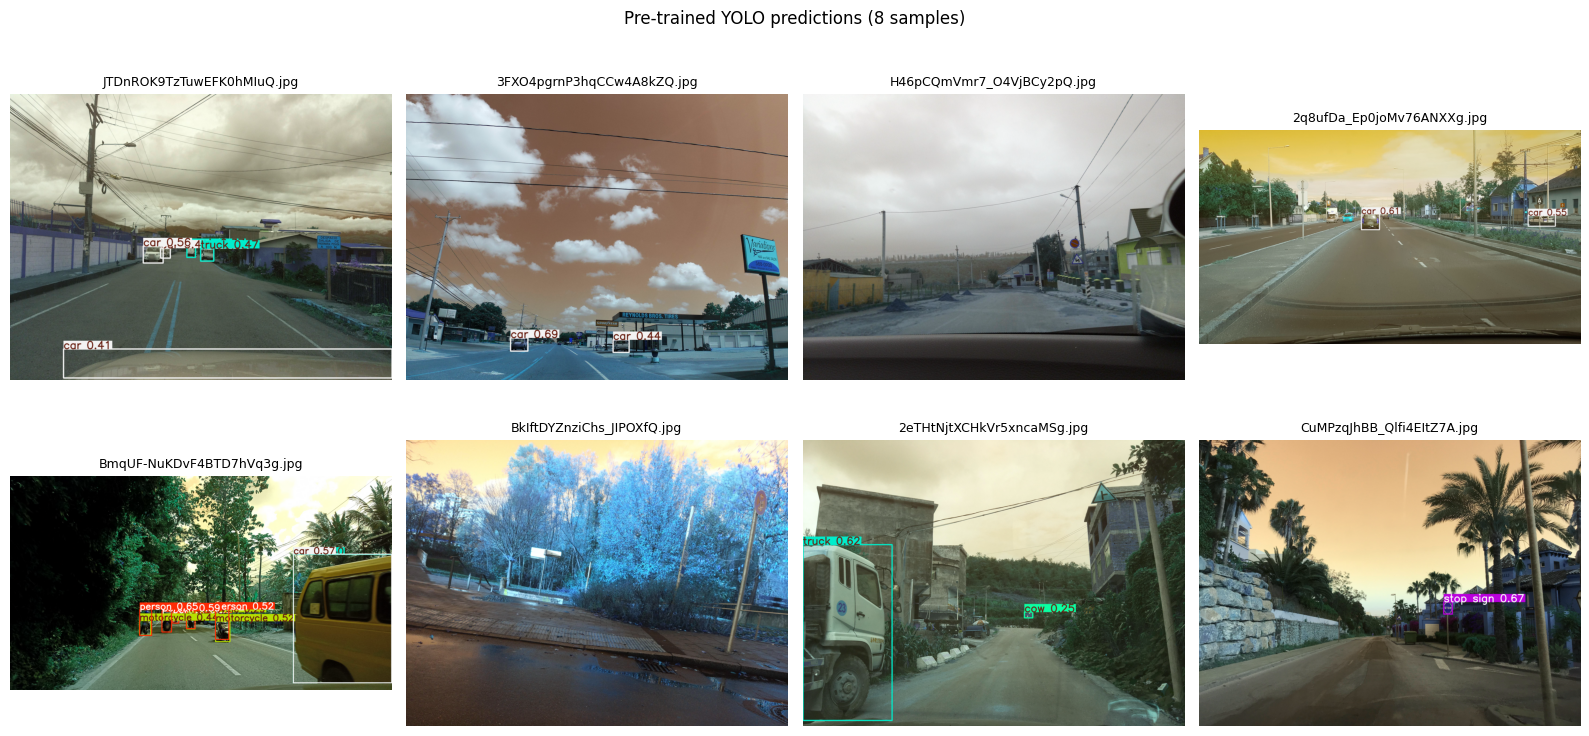

Evaluated pre-trained YOLO on 50 test images


In [5]:
# =============================================================================
# Task 3: Evaluate Pre-trained YOLO on MTSD Test Dataset
# =============================================================================
# Run inference on test images (15% randomly selected).
# Pre-trained YOLO uses COCO classes; traffic signs may map to "stop sign" etc.


test_images = list(Path("mtsd_yolo_dataset/test/images").glob("*.jpg"))[:50]  # Sample 50 test images
if test_images:
    results = model([str(p) for p in test_images])

    # Save predictions to JSON file with image paths as keys
    predictions = {}
    for i, img_path in enumerate(test_images):
        key = str(img_path)
        r = results[i]
        preds = []
        if r.boxes is not None:
            for box, conf, cls_id in zip(r.boxes.xyxy.tolist(), r.boxes.conf.tolist(), r.boxes.cls.tolist()):
                preds.append({"bbox": [float(x) for x in box], "class": r.names[int(cls_id)], "confidence": float(conf)})
        predictions[key] = preds
    with open("pretrained_predictions.json", "w") as f:
        json.dump(predictions, f, indent=2)
    print(f"Saved pre-trained predictions to pretrained_predictions.json ({len(test_images)} images)")

    # Display 8 sample images with predictions
    fig, axes = plt.subplots(2, 4, figsize=(16, 8))
    axes = axes.flatten()
    for i in range(min(8, len(test_images))):
        axes[i].imshow(results[i].plot())
        axes[i].set_title(test_images[i].name, fontsize=9)
        axes[i].axis("off")
    for j in range(min(8, len(test_images)), 8):
        axes[j].axis("off")
    plt.suptitle("Pre-trained YOLO predictions (8 samples)", fontsize=12)
    plt.tight_layout()
    plt.show()
    print(f"Evaluated pre-trained YOLO on {len(test_images)} test images")
else:
    print("No test images found. Run dataset conversion first.")


In [ ]:
# =============================================================================
# Task 4: Fine-tune YOLO for Small Object (Traffic Sign) Detection
# =============================================================================

model_train = YOLO("yolov8n.pt")
results_train = model_train.train(
    data=os.path.abspath(f"{YOLO_DATASET}/dataset.yaml"),
    epochs=20,
    imgsz=1280,  # Higher resolution for small objects
    batch=8,
    patience=10,
    project="runs/detect",
    name="mtsd_traffic_sign",
)

New https://pypi.org/project/ultralytics/8.4.24 available 😃 Update with 'pip install -U ultralytics'
Ultralytics 8.4.22 🚀 Python-3.12.3 torch-2.10.0+cu128 CUDA:0 (NVIDIA A100 80GB PCIe, 81152MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=8, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/research/bdaqiq/CSCI611_Basira_Daqiq/Assignment_3/mtsd_yolo_dataset/dataset.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=20, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=1280, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt,

In [ ]:
# =============================================================================
# Experiment 2 — Enhanced Data Augmentation
# Adds scaling, rotation (tilting), shear, translation, and color jitter
# to help the model generalize across varied sign appearances.
# =============================================================================

model_aug = YOLO("yolov8n.pt")
results_aug = model_aug.train(
    data=os.path.abspath(f"{YOLO_DATASET}/dataset.yaml"),
    epochs=20,
    imgsz=1280,
    batch=8,
    patience=10,
    # --- augmentation knobs ---
    degrees=15.0,      # rotation ±15° (tilting)
    scale=0.9,         # scale ±90% (aggressive size variation)
    shear=5.0,         # shear ±5°
    translate=0.2,     # translate ±20% of image size
    flipud=0.3,        # vertical flip 30% probability
    fliplr=0.5,        # horizontal flip 50% probability
    mosaic=1.0,        # mosaic augmentation ON
    close_mosaic=15,   # disable mosaic last 15 epochs for fine-tuning
    mixup=0.15,        # blend two images 15% probability
    hsv_h=0.02,        # hue shift
    hsv_s=0.8,         # saturation shift
    hsv_v=0.5,         # brightness shift
    erasing=0.3,       # random erasing
    project="runs/detect",
    name="mtsd_exp2_augmentation",
)


image 1/1 /research/bdaqiq/CSCI611_Basira_Daqiq/Assignment_3/mtsd_yolo_dataset/test/images/JTDnROK9TzTuwEFK0hMIuQ.jpg: 480x640 4 cars, 2 trucks, 9.0ms
Speed: 3.3ms preprocess, 9.0ms inference, 1.5ms postprocess per image at shape (1, 3, 480, 640)



image 1/1 /research/bdaqiq/CSCI611_Basira_Daqiq/Assignment_3/mtsd_yolo_dataset/test/images/JTDnROK9TzTuwEFK0hMIuQ.jpg: 960x1280 1 traffic-sign, 8.4ms
Speed: 9.7ms preprocess, 8.4ms inference, 1.4ms postprocess per image at shape (1, 3, 960, 1280)

image 1/1 /research/bdaqiq/CSCI611_Basira_Daqiq/Assignment_3/mtsd_yolo_dataset/test/images/3FXO4pgrnP3hqCCw4A8kZQ.jpg: 480x640 2 cars, 8.6ms
Speed: 3.2ms preprocess, 8.6ms inference, 1.5ms postprocess per image at shape (1, 3, 480, 640)

image 1/1 /research/bdaqiq/CSCI611_Basira_Daqiq/Assignment_3/mtsd_yolo_dataset/test/images/3FXO4pgrnP3hqCCw4A8kZQ.jpg: 960x1280 1 traffic-sign, 8.2ms
Speed: 9.8ms preprocess, 8.2ms inference, 1.4ms postprocess per image at shape (1, 3, 960, 1280)

image 1/1 /research/bdaqiq/CSCI611_Basira_Daqiq/Assignment_3/mtsd_yolo_dataset/test/images/H46pCQmVmr7_O4VjBCy2pQ.jpg: 480x640 (no detections), 7.9ms
Speed: 3.4ms preprocess, 7.9ms inference, 0.7ms postprocess per image at shape (1, 3, 480, 640)

image 1/1 /researc

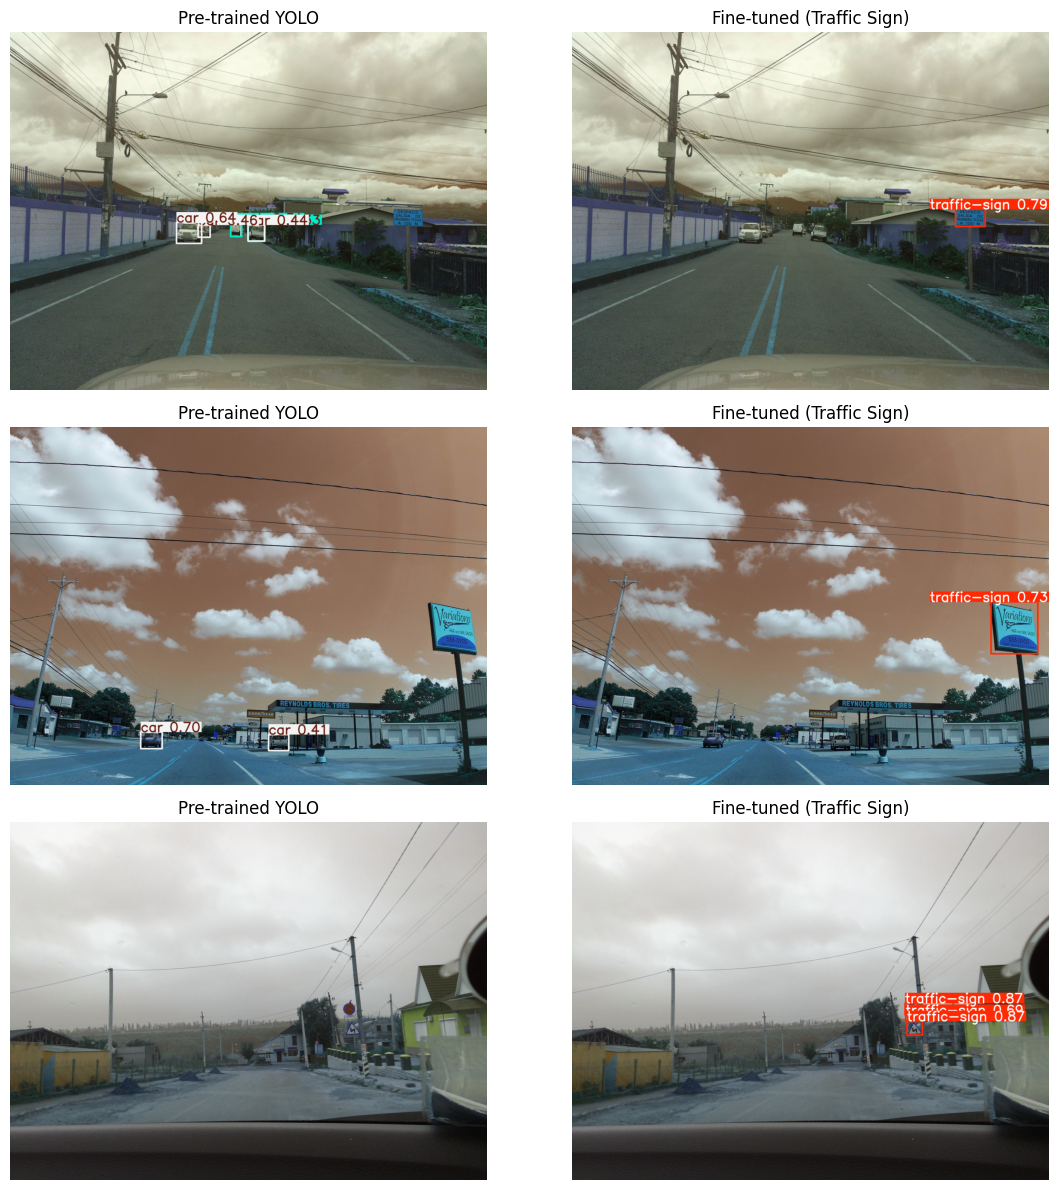

In [10]:
# =============================================================================
# Task 5: Inference and Comparison
# =============================================================================
# Compare pre-trained vs fine-tuned model on sample images

from pathlib import Path

# Load fine-tuned model (use best weights from training)
finetuned_model = YOLO("runs/detect/mtsd_traffic_sign3/weights/best.pt")

# Sample images for comparison (from test set)
sample_paths = list(Path("mtsd_yolo_dataset/test/images").glob("*.jpg"))[:3]
if not sample_paths:
    sample_paths = ["car.png", "plant.png"]  # Fallback to assignment images

fig, axes = plt.subplots(len(sample_paths), 2, figsize=(12, 4 * len(sample_paths)))
if len(sample_paths) == 1:
    axes = axes.reshape(1, -1)

for i, img_path in enumerate(sample_paths):
    path = str(img_path) if hasattr(img_path, "name") else img_path
    # Pre-trained
    r1 = model(path)
    axes[i, 0].imshow(r1[0].plot())
    axes[i, 0].set_title("Pre-trained YOLO")
    axes[i, 0].axis("off")
    # Fine-tuned
    r2 = finetuned_model(path)
    axes[i, 1].imshow(r2[0].plot())
    axes[i, 1].set_title("Fine-tuned (Traffic Sign)")
    axes[i, 1].axis("off")

plt.tight_layout()
plt.show()

In [13]:
# Validation metrics: compare pre-trained vs fine-tuned on MTSD val set
val_metrics = finetuned_model.val(data=os.path.abspath(f"{YOLO_DATASET}/dataset.yaml"))
print(f"Fine-tuned model mAP50: {val_metrics.box.map50:.3f}, mAP50-95: {val_metrics.box.map:.3f}")

Ultralytics 8.4.22 🚀 Python-3.12.3 torch-2.10.0+cu128 CUDA:0 (NVIDIA A100 80GB PCIe, 81152MiB)
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 3423.7±376.5 MB/s, size: 884.5 KB)
val: Scanning /research/bdaqiq/CSCI611_Basira_Daqiq/Assignment_3/mtsd_yolo_dataset/val/labels.cache... 1746 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 1746/1746 563.3Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 110/110 7.5it/s 14.6s0.1s
                   all       1746       8750      0.771      0.597       0.67      0.457
Speed: 1.4ms preprocess, 1.8ms inference, 0.0ms loss, 0.8ms postprocess per image
Results saved to /research/bdaqiq/CSCI611_Basira_Daqiq/runs/detect/val
Fine-tuned model mAP50: 0.670, mAP50-95: 0.457


In [6]:
# =============================================================================
# Experiment 2 — Enhanced Data Augmentation
# Adds scaling, rotation (tilting), shear, translation, and color jitter
# to help the model generalize across varied sign appearances.
# =============================================================================

model_aug = YOLO("yolov8n.pt")
results_aug = model_aug.train(
    data=os.path.abspath(f"{YOLO_DATASET}/dataset.yaml"),
    epochs=20,
    imgsz=1280,
    batch=8,
    patience=10,
    # --- augmentation knobs ---
    degrees=15.0,      # rotation ±15° (tilting)
    scale=0.9,         # scale ±90% (aggressive size variation)
    shear=5.0,         # shear ±5°
    translate=0.2,     # translate ±20% of image size
    flipud=0.3,        # vertical flip 30% probability
    fliplr=0.5,        # horizontal flip 50% probability
    mosaic=1.0,        # mosaic augmentation ON
    close_mosaic=15,   # disable mosaic last 15 epochs for fine-tuning
    mixup=0.15,        # blend two images 15% probability
    hsv_h=0.02,        # hue shift
    hsv_s=0.8,         # saturation shift
    hsv_v=0.5,         # brightness shift
    erasing=0.3,       # random erasing
    project="runs/detect",
    name="mtsd_exp2_augmentation",
)

New https://pypi.org/project/ultralytics/8.4.31 available 😃 Update with 'pip install -U ultralytics'
Ultralytics 8.4.22 🚀 Python-3.12.3 torch-2.10.0+cu128 CUDA:0 (NVIDIA A100 80GB PCIe, 81152MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=8, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=15, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/research/bdaqiq/CSCI611_Basira_Daqiq/Assignment_3/mtsd_yolo_dataset/dataset.yaml, degrees=15.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=20, erasing=0.3, exist_ok=False, fliplr=0.5, flipud=0.3, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.02, hsv_s=0.8, hsv_v=0.5, imgsz=1280, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.15, mode=train, model=yolov8n.pt


image 1/1 /research/bdaqiq/CSCI611_Basira_Daqiq/Assignment_3/mtsd_yolo_dataset/test/images/JTDnROK9TzTuwEFK0hMIuQ.jpg: 960x1280 1 traffic-sign, 11.1ms
Speed: 11.6ms preprocess, 11.1ms inference, 1.9ms postprocess per image at shape (1, 3, 960, 1280)

image 1/1 /research/bdaqiq/CSCI611_Basira_Daqiq/Assignment_3/mtsd_yolo_dataset/test/images/JTDnROK9TzTuwEFK0hMIuQ.jpg: 960x1280 1 traffic-sign, 10.2ms
Speed: 11.3ms preprocess, 10.2ms inference, 1.8ms postprocess per image at shape (1, 3, 960, 1280)

image 1/1 /research/bdaqiq/CSCI611_Basira_Daqiq/Assignment_3/mtsd_yolo_dataset/test/images/3FXO4pgrnP3hqCCw4A8kZQ.jpg: 960x1280 1 traffic-sign, 9.9ms
Speed: 11.3ms preprocess, 9.9ms inference, 2.0ms postprocess per image at shape (1, 3, 960, 1280)

image 1/1 /research/bdaqiq/CSCI611_Basira_Daqiq/Assignment_3/mtsd_yolo_dataset/test/images/3FXO4pgrnP3hqCCw4A8kZQ.jpg: 960x1280 3 traffic-signs, 9.9ms
Speed: 13.3ms preprocess, 9.9ms inference, 2.0ms postprocess per image at shape (1, 3, 960, 1280)

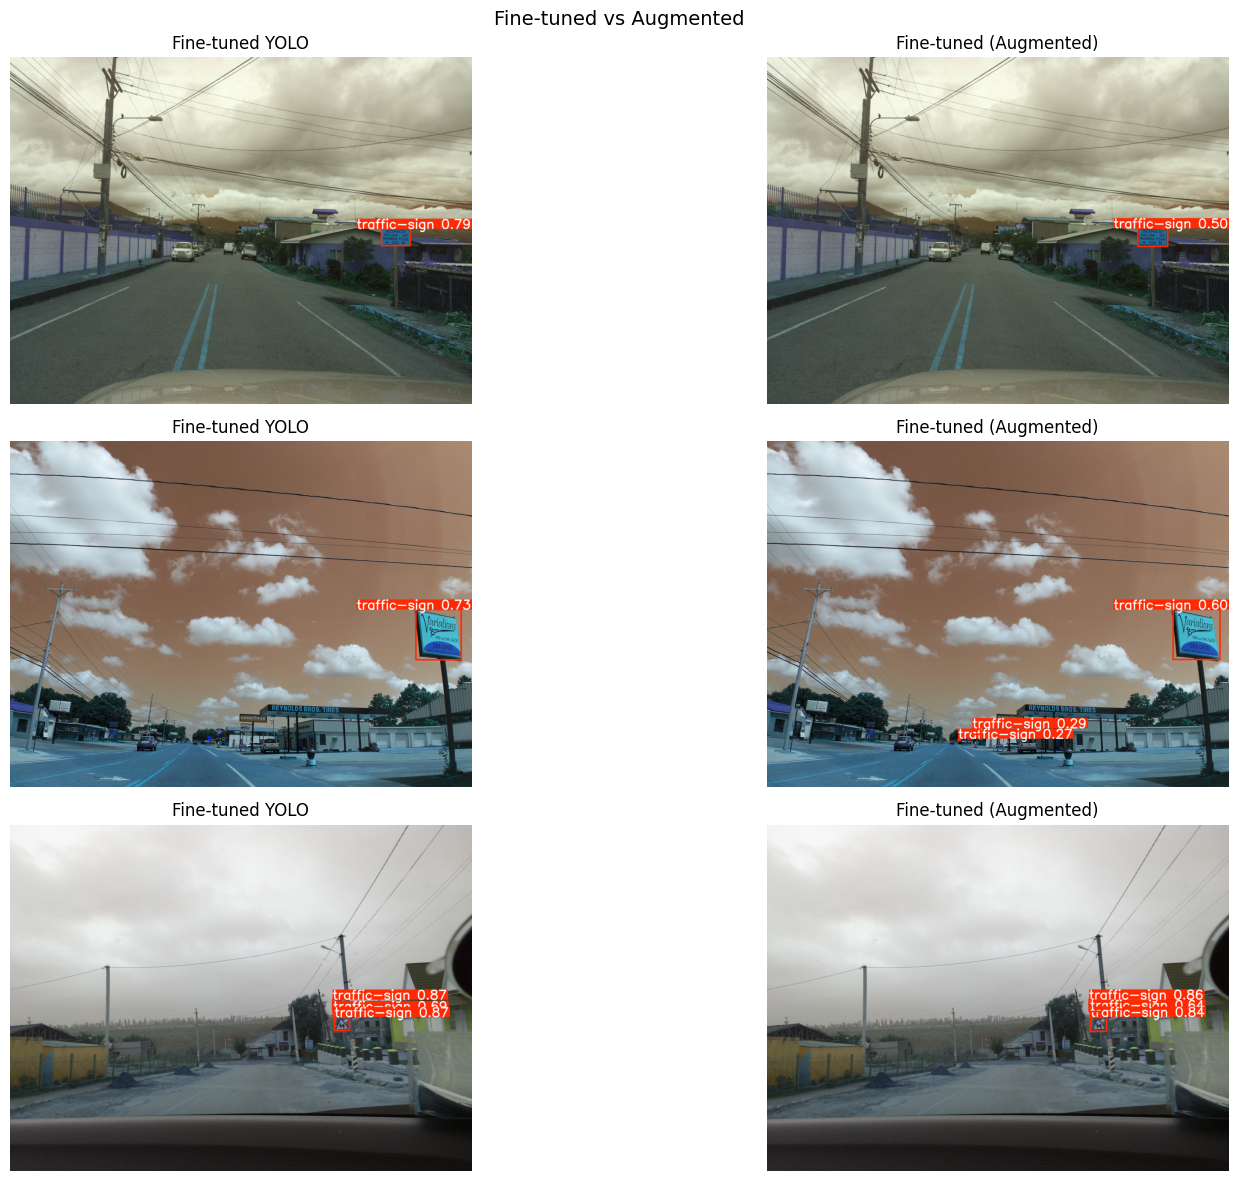

Ultralytics 8.4.22 🚀 Python-3.12.3 torch-2.10.0+cu128 CUDA:0 (NVIDIA A100 80GB PCIe, 81152MiB)
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 2339.3±632.8 MB/s, size: 824.2 KB)
val: Scanning /research/bdaqiq/CSCI611_Basira_Daqiq/Assignment_3/mtsd_yolo_dataset/val/labels.cache... 1746 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 1746/1746 366.2Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 110/110 6.2it/s 17.7s0.1s
                   all       1746       8750       0.76      0.565       0.64      0.393
Speed: 2.0ms preprocess, 1.6ms inference, 0.0ms loss, 1.0ms postprocess per image
Results saved to /research/bdaqiq/CSCI611_Basira_Daqiq/runs/detect/val3

--- Experiment 2 (Augmented) ---
mAP50:    0.640
mAP50-95: 0.393
Precision: 0.760
Recall:    0.565


In [13]:
# =============================================================================
# Experiment 2 — Results: compare pre-trained vs baseline fine-tuned vs augmented
# Uses the same sample images as the Task 5 comparison cell.
# =============================================================================

aug_model = YOLO("runs/detect/mtsd_exp2_augmentation/weights/best.pt")

sample_paths = list(Path("mtsd_yolo_dataset/test/images").glob("*.jpg"))[:3]
if not sample_paths:
    sample_paths = ["car.png", "plant.png"]

fig, axes = plt.subplots(len(sample_paths), 2, figsize=(18, 4 * len(sample_paths)))
if len(sample_paths) == 1:
    axes = axes.reshape(1, -1)

for i, img_path in enumerate(sample_paths):
    path = str(img_path) if hasattr(img_path, "name") else img_path

    r1 = finetuned_model(path)
    axes[i, 0].imshow(r1[0].plot())
    axes[i, 0].set_title("Fine-tuned YOLO")
    axes[i, 0].axis("off")


    r2 = aug_model(path)
    axes[i, 1].imshow(r2[0].plot())
    axes[i, 1].set_title("Fine-tuned (Augmented)")
    axes[i, 1].axis("off")

plt.suptitle("Fine-tuned vs Augmented", fontsize=14)
plt.tight_layout()
plt.show()

# Validation metrics for augmented model
aug_metrics = aug_model.val(data=os.path.abspath(f"{YOLO_DATASET}/dataset.yaml"))
print(f"\n--- Experiment 2 (Augmented) ---")
print(f"mAP50:    {aug_metrics.box.map50:.3f}")
print(f"mAP50-95: {aug_metrics.box.map:.3f}")
print(f"Precision: {aug_metrics.box.mp:.3f}")
print(f"Recall:    {aug_metrics.box.mr:.3f}")